### NCF & Stacks

In [30]:
# Import necessary dependencies
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.append('..')
from src.plot import plot_ncf_section, plot_ncf_section_mesh, plot_fv_panel, plot_fv_panel_mesh, plot_fv_with_pick, plot_fv_with_pick_mesh
from src.utils import parse_ncf_filename, fk_filter, compute_envelope, convert_to_numpy
from src.disp import dispersion_curve, extr_disp
from src.error import ssim_index

In [3]:
vs_idx ='070'

# Define NCF paths (conventional)
ncf_monthly_c = f'../data/ncf_stacks/30d/20210928_cc_{vs_idx}_30d_conventional.npy'
filename_c = f'20210928_cc_{vs_idx}_7d_conventional.npy'

# Define NCF paths (v1)
ncf_monthly_v = f'../data/ncf_stacks/30d/20210928_cc_{vs_idx}_30d_v1.npy'
filename_v = f'20210928_cc_{vs_idx}_7d_v1.npy'


ncf_monthly_con = np.load(ncf_monthly_c)
ncf_monthly_v1 = np.load(ncf_monthly_v)

# Extract parameters
_, vs, window = parse_ncf_filename(ncf_monthly_v)
# Define parameters
dt = 0.004      # sampling rate in sec (or 250 Hz)
fs = 250        # sampling frequency (Hz)

# Max lag and sample rate
max_lag = 2.0   # seconds 
npts_lag = int(max_lag * fs)

# Cable configuration
first_chan = 399
last_chan = 748
dx = 8.16       # `chann_len` in meters
channels = np.arange(first_chan, last_chan + 1)

n_rec, n_lags = ncf_monthly_v1.shape
# Lag axis spans from –max_lag ... +max_lag
lag_axis = np.linspace(-max_lag, +max_lag, n_lags)

if len(channels) != n_rec:
    channels = np.arange(n_rec)

distance_axis = (channels - channels[0]) * dx

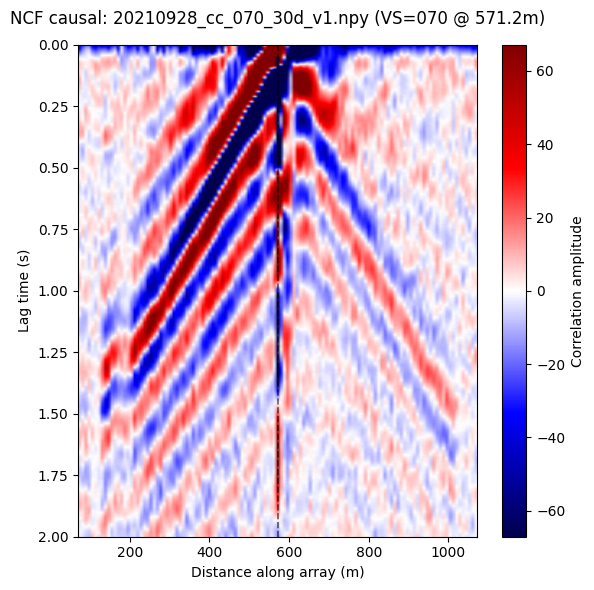

In [14]:
ncf_monthly_v1_clip = np.percentile(np.abs(ncf_monthly_v1), 99)
plot_ncf_section_mesh(
    ncf=ncf_monthly_v1,          # NCF data (np.ndarray)
    lag_axis=lag_axis,           # lag time array
    distance_axis=distance_axis, # distance array
    mode="causal",                  # Options: "all", "causal", "acausal"
    clip=ncf_monthly_v1_clip,       # Amplitude clipping value
    filename=ncf_monthly_v,      # String used for the title/saving
    vs=vs,                       # Virtual source position as string
    gauge_length=8.16,           # Distance between sensors
    range_m=500,                 # How many meters to show left/right
    clip_lim=True                # Enable the x-axis zoom
)

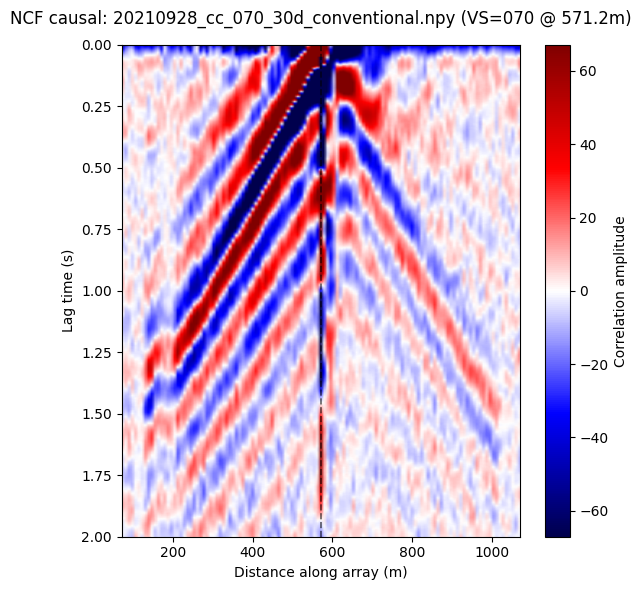

In [15]:
ncf_monthly_con_clip = np.percentile(np.abs(ncf_monthly_con), 99)
plot_ncf_section_mesh(
    ncf=ncf_monthly_con,          # NCF data (np.ndarray)
    lag_axis=lag_axis,           # lag time array
    distance_axis=distance_axis, # distance array
    mode="causal",                  # Options: "all", "causal", "acausal"
    clip=ncf_monthly_con_clip,       # Amplitude clipping value
    filename=ncf_monthly_c,      # String used for the title/saving
    vs=vs,                       # Virtual source position as string
    gauge_length=8.16,           # Distance between sensors
    range_m=500,                 # How many meters to show left/right
    clip_lim=True                # Enable the x-axis zoom
)

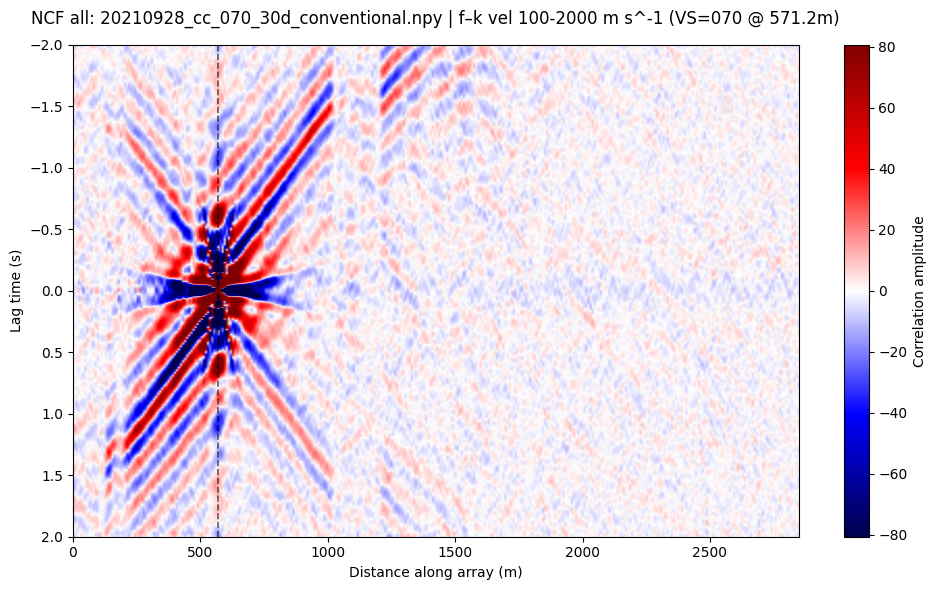

In [18]:
# f-k range
vmin = 100
vmax = 2000

ncf_monthly_fk_con = fk_filter(
    ncf_monthly_con,
    dt=dt,
    dx=dx,
    vmin=vmin,
    vmax=vmax,
    mode="extract",       # Keep the data inside the cone
    smooth="gaussian",    # Prevent ringing
    sigma=2.0             # A safe, standard softness
)

ncf_monthly_fk_clip = np.percentile(np.abs(ncf_monthly_fk_con), 99)
plot_ncf_section_mesh(ncf_monthly_fk_con, lag_axis, distance_axis, mode="all", clip=ncf_monthly_fk_clip, filename=f"{ncf_monthly_c} | f–k vel {vmin}-{vmax} m s^-1", vs=vs, range_m=500, clip_lim=False)

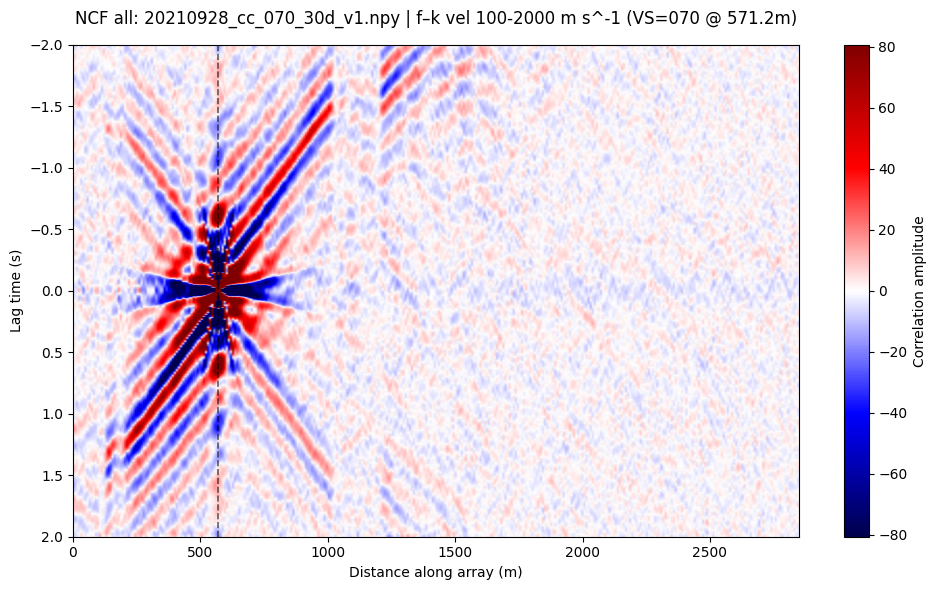

In [19]:
# f-k range
vmin = 100
vmax = 2000

ncf_monthly_fk_v1 = fk_filter(
    ncf_monthly_v1,
    dt=dt,
    dx=dx,
    vmin=vmin,
    vmax=vmax,
    mode="extract",       # Keep the data inside the cone
    smooth="gaussian",    # Prevent ringing
    sigma=2.0             # A safe, standard softness
)

ncf_monthly_fk_clip = np.percentile(np.abs(ncf_monthly_fk_v1), 99)
plot_ncf_section_mesh(ncf_monthly_fk_v1, lag_axis, distance_axis, mode="all", clip=ncf_monthly_fk_clip, filename=f"{ncf_monthly_v} | f–k vel {vmin}-{vmax} m s^-1", vs=vs, range_m=500, clip_lim=False)

In [20]:
def prep_ncf(
    ncf: np.ndarray, 
    lag_axis: np.ndarray, 
    distance_axis: np.ndarray, 
    vs: str, 
    gauge_length: float = 8.16):
    """
    Separates NCF into causal/acausal parts and performs spatial-temporal 
    recombination to group energy by source direction.

    Returns:
        causal_data (np.ndarray): ncf_c (0...+T)
        acausal_data (np.ndarray): ncf_a (0...+T flipped)
        new_lag_axis (np.ndarray): Positive lag axis (0 to T)
        ncf_s1 (np.ndarray): Combined [A | D]
        ncf_s2 (np.ndarray): Combined [C | B]
    """
    ncf = np.asarray(ncf)
    lag_axis = np.asarray(lag_axis)
    distance_axis = np.asarray(distance_axis)

    # Safeguard: ensure (n_dist, n_lag)
    if ncf.shape[1] != lag_axis.size and ncf.shape[0] == lag_axis.size:
        ncf = ncf.T

    # --- 1. Basic Time Separation ---
    c_sel = lag_axis >= 0
    ncf_c = ncf[:, c_sel]
    new_lag_axis = lag_axis[c_sel]

    # Extract Acausal (Lag <= 0) and flip time
    a_sel = lag_axis <= 0
    ncf_a = ncf[:, a_sel][:, ::-1]

    # --- 2. Spatial-Temporal Splitting ---
    position = int(vs) * gauge_length
    # Find index closest to the calculated meter position
    vs_idx = np.argmin(np.abs(distance_axis - position))

    # Decompose ncf_c (Causal) into A and B
    A = ncf_c[:vs_idx, :] # Distances < VS
    B = ncf_c[vs_idx:, :] # Distances >= VS

    # Decompose ncf_a (Acausal) into C and D
    C = ncf_a[:vs_idx, :] # Distances < VS
    D = ncf_a[vs_idx:, :] # Distances >= VS

    # --- 3. Source-consistent Recombination ---
    # ncf_s1: Combining waves from one side [A | D]
    ncf_s1 = np.vstack([A, D])

    # ncf_s2: Combining waves from the other side [C | B]
    ncf_s2 = np.vstack([C, B])

    return ncf_c, ncf_a, new_lag_axis, ncf_s1, ncf_s2

In [21]:
def clip_ncf_side(
    data: np.ndarray, 
    distance_axis: np.ndarray, 
    vs: str, 
    range_m: float, 
    side: str = "right", 
    pos_offset: float = 0.0,
    gauge_length: float = 8.16
):
    """
    Clips NCF spatially to one side of the virtual source with an optional inner offset.
    
    side="right": [position + pos_offset, position + range_m]
    side="left":  [position - range_m, position - pos_offset]
    """
    position = int(vs) * gauge_length
    
    if side.lower() == "right":
        lower = position + pos_offset
        upper = position + range_m
    elif side.lower() == "left":
        lower = position - range_m
        upper = position - pos_offset
    else:
        raise ValueError("side must be 'left' or 'right'")

    # Apply absolute boundaries based on the array extent
    lower = max(distance_axis.min(), lower)
    upper = min(distance_axis.max(), upper)

    # Ensure lower doesn't exceed upper if offset is too large
    if lower > upper:
        raise ValueError(f"pos_offset ({pos_offset}m) is larger than the available range.")
    
    # Find indices
    idx_sel = (distance_axis >= lower) & (distance_axis <= upper)
    
    return data[idx_sel, :], distance_axis[idx_sel]

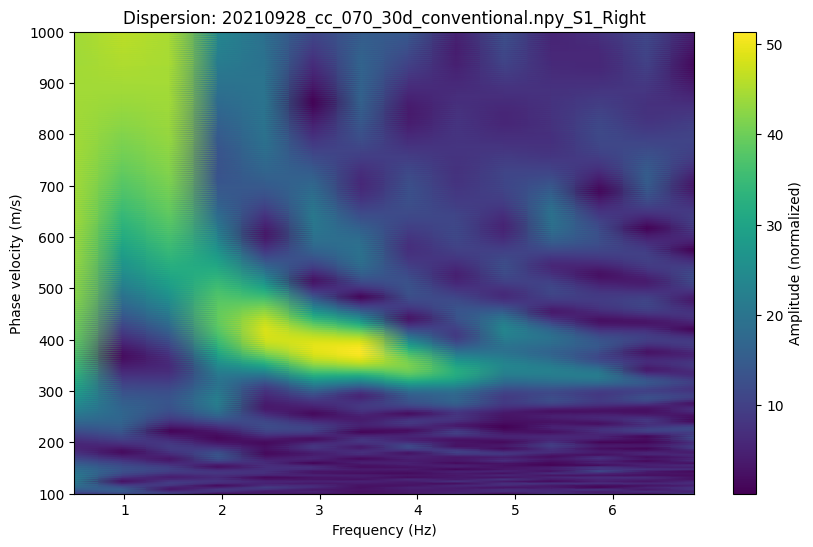

In [28]:
ncf_c, ncf_a, half_lag, s1, s2 = prep_ncf(
    ncf_monthly_fk_con, 
    lag_axis, 
    distance_axis, 
    vs=vs, 
    gauge_length=8.16
)

# Clip to only show the right side of the VS
s1_right, dist_right = clip_ncf_side(s1, distance_axis, vs, range_m=500, side="right", pos_offset=0.0)

# --- Parameters from disp.yaml ---
gauge_length = 8.16
fv_kwargs = {
    "vmin": 100.0,
    "vmax": 1000.0,
    "dv": 4.0,
    "fmin": 0.1,
    "fmax": 7.0,
    "normalize": False,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# --- Prepare the spatial offsets ---
# Ensure the virtual source is at 0.0 m for the Phase-Shift method
relative_offsets = dist_right - (int(vs) * gauge_length)  

# --- Compute f-v panel ---
# s1_right shape (n_dist, n_lag), half_lag shape (n_lag,)
fv_s1_con, f_axis_s1, v_axis_s1 = dispersion_curve(
    data=s1_right, 
    offset=relative_offsets, 
    t=half_lag, 
    **fv_kwargs
)

# --- Compute Picks ---
picks_s1 = extr_disp(
    f_axis_s1, v_axis_s1, fv_s1_con, 
    f_ref_set= [2, 3], 
    vmax_set=[500, 400], 
    step=5
)

fig, ax = plot_fv_panel_mesh(
    fv_s1_con, 
    f_axis_s1, 
    v_axis_s1, 
    filename=f"{ncf_monthly_c}_S1_Right",
    cmap="viridis" 
)

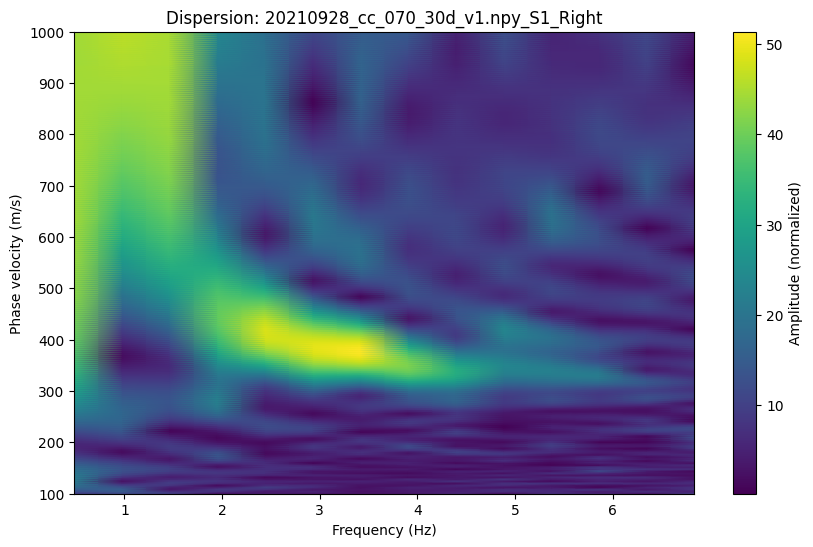

In [29]:
ncf_c, ncf_a, half_lag, s1, s2 = prep_ncf(
    ncf_monthly_fk_v1, 
    lag_axis, 
    distance_axis, 
    vs=vs, 
    gauge_length=8.16
)

# Clip to only show the right side of the VS
s1_right, dist_right = clip_ncf_side(s1, distance_axis, vs, range_m=500, side="right", pos_offset=0.0)

# --- Parameters from disp.yaml ---
gauge_length = 8.16
fv_kwargs = {
    "vmin": 100.0,
    "vmax": 1000.0,
    "dv": 4.0,
    "fmin": 0.1,
    "fmax": 7.0,
    "normalize": False,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# --- Prepare the spatial offsets ---
# Ensure the virtual source is at 0.0 m for the Phase-Shift method
relative_offsets = dist_right - (int(vs) * gauge_length)  

# --- Compute f-v panel ---
# s1_right shape (n_dist, n_lag), half_lag shape (n_lag,)
fv_s1_v1, f_axis_s1, v_axis_s1 = dispersion_curve(
    data=s1_right, 
    offset=relative_offsets, 
    t=half_lag, 
    **fv_kwargs
)

# --- Compute Picks ---
picks_s1 = extr_disp(
    f_axis_s1, v_axis_s1, fv_s1_v1, 
    f_ref_set= [2, 3], 
    vmax_set=[500, 400], 
    step=5
)

fig, ax = plot_fv_panel_mesh(
    fv_s1_v1, 
    f_axis_s1, 
    v_axis_s1, 
    filename=f"{ncf_monthly_v}_S1_Right",
    cmap="viridis" 
)

In [31]:
fv_s1_v1_np  = convert_to_numpy(fv_s1_v1)
fv_s1_con_np = convert_to_numpy(fv_s1_con)

In [33]:
score = ssim_index(
    D_ref=fv_s1_con_np,   # reference (conventional)
    D_test=fv_s1_v1_np,   # Zhang v1
    p=99.5,
    gaussian_weights=True,
    sigma=1.5,
)

print("SSIM =", score)

SSIM = 1.0
